In [1]:
import pandas as pd

In [2]:
df = pd.read_csv(r"C:\Users\solay\Documents\OneDrive\OpenClassrooms\P5\QueryResults.csv")

In [3]:
df

,Title,Body,Tags,Id,Score,ViewCount,FavoriteCount,AnswerCount
0,Paging a collection with LINQ,<p>How do you page through a collection in LIN...,<linq><.net-3.5>,66,89,6427,NaN,4
1,How do I add existing comments to RDoc in Ruby?,<p>I want to format my existing comments as 'R...,<ruby><rdoc>,72,48,2232,NaN,2
2,Getting Subclipse in Aptana to work with the n...,<p>The version of <strong>Subclipse (1.2.4)</s...,<eclipse><svn><aptana><subclipse>,79,50,11502,NaN,4
3,SQLStatement.execute() - multiple queries in o...,<p>I've written a database generation script i...,<apache-flex><actionscript-3><air>,80,54,6774,NaN,3
4,Flat file databases,<p>What are the best practices around creating...,<php><sql><database><flat-file>,85,133,70693,NaN,11
...,...,...,...,...,...,...,...,...
49995,Collection initialization syntax in Visual Bas...,<p>I'm trying to determine if there's a way in...,<vb.net><visual-studio-2008><collections><init...,85892,24,7014,NaN,2
49996,Is there a tutorial that teaches common Ruby p...,<p>I'm looking for a Ruby's equivalent of <a h...,<ruby><idioms>,85916,30,1848,NaN,8
49997,XML Notepad 2007 breaks MS Access 2007 Help,<p>I tried scouring the web for help on this i...,<xml><ms-office>,85923,0,961,NaN,2
49998,Why do I need a flickr api key?,<p>Reading through the Flickr API documentatio...,<flickr>,86163,16,14868,NaN,5


In [4]:
from bs4 import BeautifulSoup

def remove_html_tags(text):
    return BeautifulSoup(text, "html.parser").get_text()

df['Body_no_html'] = df['Body'].apply(remove_html_tags)

In [5]:
df_top100 = df.groupby('Tags').size().sort_values(ascending=False).head(100)

In [6]:
df = df[:100]

In [ ]:
import spacy

# Download the English model if not already present
try:
    nlp = spacy.load("en_core_web_sm")
except OSError:
    from spacy.cli import download
    download("en_core_web_sm")
    nlp = spacy.load("en_core_web_sm")

def clean_text(text):
    

df['cleaned_Body'] = df['Body_no_html'].apply(clean_text)

C:\Users\solay\AppData\Local\Temp\ipykernel_39596\3902796236.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['cleaned_Body'] = df['Body_no_html'].apply(clean_text)


In [8]:
df['cleaned_Body']

0            page collection linq give startindex count
1     want format exist comment rdoc comment view ri...
2     version subclipse 1.2.4 currently available ap...
3     write database generation script sql want exec...
4     good practice create flat file database struct...
                            ...                        
95    get window service run domain account specify ...
96    need navigation click event ipad app mean clic...
97    try serialize object store sd card essentially...
98    try develop j2me sms application symbian impor...
99    try create list show audio video mediastore su...
Name: cleaned_Body, Length: 100, dtype: object

In [9]:
df['cleaned_Title'] = df['Title'].apply(clean_text)

C:\Users\solay\AppData\Local\Temp\ipykernel_39596\2371015484.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['cleaned_Title'] = df['Title'].apply(clean_text)


In [10]:
df['cleaned_Title']

0                                 page collection linq
1                          add exist comment rdoc ruby
2     get subclipse aptana work new release subversion
3        sqlstatement.execute multiple query statement
4                                   flat file database
                            ...                       
95                let user specify account service run
96               handle click event element hold event
97      find reason java.io optionaldataexception code
98                      simple j2me sms code debugging
99             listview display audio video mediastore
Name: cleaned_Title, Length: 100, dtype: object

In [11]:
df

,Title,Body,Tags,Id,Score,ViewCount,FavoriteCount,AnswerCount,Body_no_html,cleaned_Body,cleaned_Title
0,Paging a collection with LINQ,<p>How do you page through a collection in LIN...,<linq><.net-3.5>,66,89,6427,NaN,4,How do you page through a collection in LINQ g...,page collection linq give startindex count,page collection linq
1,How do I add existing comments to RDoc in Ruby?,<p>I want to format my existing comments as 'R...,<ruby><rdoc>,72,48,2232,NaN,2,I want to format my existing comments as 'RDoc...,want format exist comment rdoc comment view ri...,add exist comment rdoc ruby
2,Getting Subclipse in Aptana to work with the n...,<p>The version of <strong>Subclipse (1.2.4)</s...,<eclipse><svn><aptana><subclipse>,79,50,11502,NaN,4,The version of Subclipse (1.2.4) currently ava...,version subclipse 1.2.4 currently available ap...,get subclipse aptana work new release subversion
3,SQLStatement.execute() - multiple queries in o...,<p>I've written a database generation script i...,<apache-flex><actionscript-3><air>,80,54,6774,NaN,3,I've written a database generation script in S...,write database generation script sql want exec...,sqlstatement.execute multiple query statement
4,Flat file databases,<p>What are the best practices around creating...,<php><sql><database><flat-file>,85,133,70693,NaN,11,What are the best practices around creating fl...,good practice create flat file database struct...,flat file database
...,...,...,...,...,...,...,...,...,...,...,...
95,Let the user specify in which account a servic...,<p>I've got a windows service that should run ...,<wix>,9568169,7,6766,NaN,1,I've got a windows service that should run und...,get window service run domain account specify ...,let user specify account service run
96,"how to handle a click event only on, the eleme...",<p>I need to make a show navigation click even...,<jquery>,9568171,0,69,NaN,1,I need to make a show navigation click event t...,need navigation click event ipad app mean clic...,handle click event element hold event
97,Cannot find reason for java.io.OptionalDataExc...,<p>I'm trying to serialize an object and store...,<java><android><serialization><deserialization>,9568177,1,4303,NaN,2,I'm trying to serialize an object and store it...,try serialize object store sd card essentially...,find reason java.io optionaldataexception code
98,Simple J2ME SMS code debugging,<p>I'm trying to develop J2ME SMS applications...,<debugging><java-me><midp><netbeans-7><wma>,9568181,1,1031,NaN,1,I'm trying to develop J2ME SMS applications (o...,try develop j2me sms application symbian impor...,simple j2me sms code debugging


In [12]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer

# Séparation en train/test (80% train, 20% test)
body_train, body_test = train_test_split(df['cleaned_Body'], test_size=0.2, random_state=42)

# Approche 1 : fit et transform sur "Body" Train, transform sur "Body" Test
vectorizer_body = CountVectorizer()
X_train_body = vectorizer_body.fit_transform(body_train)
X_test_body = vectorizer_body.transform(body_test)

# Approche 2 : fit et transform sur "Title" Train, transform sur "Title" Test
title_train = df.loc[body_train.index, 'Title']
title_test = df.loc[body_test.index, 'Title']
vectorizer_title = CountVectorizer()
X_train_title = vectorizer_title.fit_transform(title_train)
X_test_title = vectorizer_title.transform(title_test)

# Approche 3 : fit sur "Title" Train, transform sur "Title" + "Body" Test
title_body_train = title_train
title_body_test = title_test + " " + body_test
vectorizer_title2 = CountVectorizer()
X_train_title2 = vectorizer_title2.fit_transform(title_body_train)
X_test_title2 = vectorizer_title2.transform(title_body_test)

# Approche 4 : fit sur "Body" Train, transform sur "Title" + "Body" Test
title_body_test2 = title_test + " " + body_test
X_test_body2 = vectorizer_body.transform(title_body_test2)

,Title,Body,Tags,Id,Score,ViewCount,FavoriteCount,AnswerCount,Body_no_html,cleaned_Body,cleaned_Title
0,Paging a collection with LINQ,<p>How do you page through a collection in LIN...,<linq><.net-3.5>,66,89,6427,NaN,4,How do you page through a collection in LINQ g...,page collection linq give startindex count,page collection linq
1,How do I add existing comments to RDoc in Ruby?,<p>I want to format my existing comments as 'R...,<ruby><rdoc>,72,48,2232,NaN,2,I want to format my existing comments as 'RDoc...,want format exist comment rdoc comment view ri...,add exist comment rdoc ruby
2,Getting Subclipse in Aptana to work with the n...,<p>The version of <strong>Subclipse (1.2.4)</s...,<eclipse><svn><aptana><subclipse>,79,50,11502,NaN,4,The version of Subclipse (1.2.4) currently ava...,version subclipse 1.2.4 currently available ap...,get subclipse aptana work new release subversion
3,SQLStatement.execute() - multiple queries in o...,<p>I've written a database generation script i...,<apache-flex><actionscript-3><air>,80,54,6774,NaN,3,I've written a database generation script in S...,write database generation script sql want exec...,sqlstatement.execute multiple query statement
4,Flat file databases,<p>What are the best practices around creating...,<php><sql><database><flat-file>,85,133,70693,NaN,11,What are the best practices around creating fl...,good practice create flat file database struct...,flat file database


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Title          100 non-null    object 
 1   Body           100 non-null    object 
 2   Tags           100 non-null    object 
 3   Id             100 non-null    int64  
 4   Score          100 non-null    int64  
 5   ViewCount      100 non-null    int64  
 6   FavoriteCount  0 non-null      float64
 7   AnswerCount    100 non-null    int64  
 8   Body_no_html   100 non-null    object 
 9   cleaned_Body   100 non-null    object 
 10  cleaned_Title  100 non-null    object 
dtypes: float64(1), int64(4), object(6)
memory usage: 8.7+ KB


,Id,Score,ViewCount,FavoriteCount,AnswerCount
count,1.000000e+02,100.000000,100.000000,0.0,100.000000
mean,2.393077e+06,73.840000,44953.250000,NaN,6.140000
std,4.163366e+06,166.873249,138217.046449,NaN,7.232111
min,6.600000e+01,-1.000000,69.000000,NaN,1.000000
25%,6.507500e+02,14.750000,2352.750000,NaN,2.000000
50%,2.227000e+03,27.000000,6409.500000,NaN,4.000000
75%,2.394267e+06,57.250000,19009.500000,NaN,8.000000
max,9.568182e+06,1269.000000,986895.000000,NaN,46.000000


Nombre de valeurs uniques dans 'Tags': 99
Exemples de tags : ['<linq><.net-3.5>' '<ruby><rdoc>' '<eclipse><svn><aptana><subclipse>'
 '<apache-flex><actionscript-3><air>' '<php><sql><database><flat-file>']


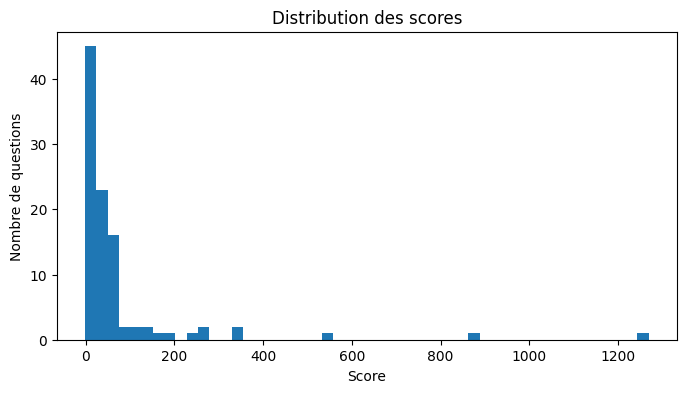

C:\Users\solay\AppData\Local\Temp\ipykernel_39596\1865599281.py:27: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['title_length'] = df['Title'].apply(len)
C:\Users\solay\AppData\Local\Temp\ipykernel_39596\1865599281.py:28: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['body_length'] = df['Body_no_html'].apply(len)


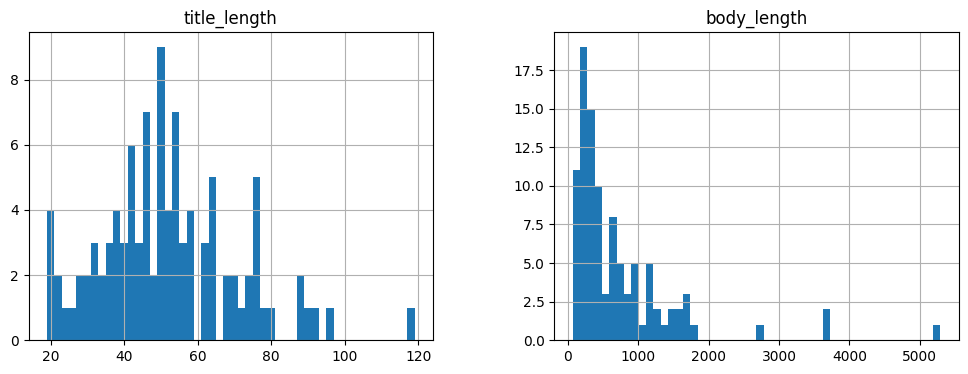

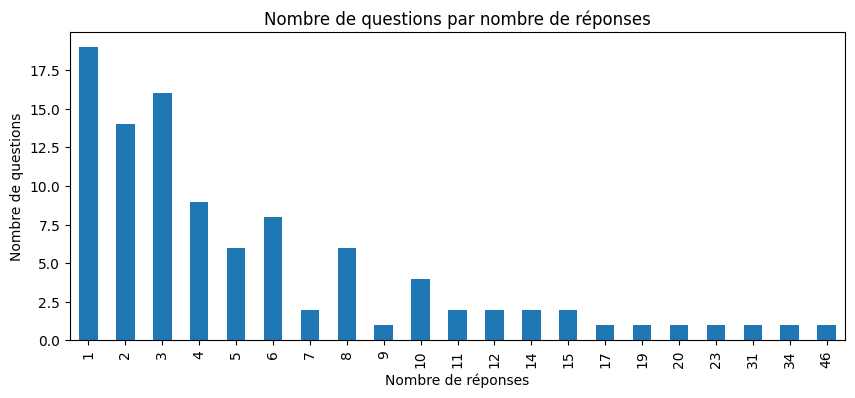

In [13]:
import matplotlib.pyplot as plt


# Analyse exploratoire de base

# Aperçu des premières lignes
display(df.head())

# Informations générales sur le DataFrame
df.info()

# Statistiques descriptives sur les colonnes numériques
display(df.describe())

# Statistiques sur les colonnes textuelles
print("Nombre de valeurs uniques dans 'Tags':", df['Tags'].nunique())
print("Exemples de tags :", df['Tags'].unique()[:5])

# Distribution des scores
df['Score'].hist(bins=50, figsize=(8, 4), grid=False)
plt.title("Distribution des scores")
plt.xlabel("Score")
plt.ylabel("Nombre de questions")
plt.show()

# Longueur des titres et des corps
df['title_length'] = df['Title'].apply(len)
df['body_length'] = df['Body_no_html'].apply(len)
df[['title_length', 'body_length']].hist(bins=50, figsize=(12, 4))
plt.show()

# Nombre de questions par nombre de réponses
df['AnswerCount'].value_counts().sort_index().plot(kind='bar', figsize=(10,4))
plt.title("Nombre de questions par nombre de réponses")
plt.xlabel("Nombre de réponses")
plt.ylabel("Nombre de questions")
plt.show()

In [14]:
df.dtypes

Title             object
Body              object
Tags              object
Id                 int64
Score              int64
ViewCount          int64
FavoriteCount    float64
AnswerCount        int64
Body_no_html      object
cleaned_Body      object
cleaned_Title     object
title_length       int64
body_length        int64
dtype: object

In [15]:
from sklearn.decomposition import LatentDirichletAllocation

# Utilisons le bag-of-words du body pour la LDA
n_topics = 10  # nombre de topics, à ajuster selon le besoin

lda = LatentDirichletAllocation(n_components=n_topics, random_state=42)
lda.fit(X_train_body)

# Affichage des mots les plus importants pour chaque topic
feature_names = vectorizer_body.get_feature_names_out()
for idx, topic in enumerate(lda.components_):
    print(f"Topic {idx+1}: ", " ".join([feature_names[i] for i in topic.argsort()[-10:][::-1]]))

Topic 1:  version value leak application memory need word file user way
Topic 2:  script js ru www http src uhwc porv function value
Topic 3:  user use net application set domain validation bit asp want
Topic 4:  text mediastore audio like video control sql server look encode
Topic 5:  use class code cli reference add file datum project need
Topic 6:  page image uri content load pic like new match use
Topic 7:  java objectinputstream system 18 05 35 warn err 23 03
Topic 8:  url setter window event value function somecontrol open property local
Topic 9:  current_ip end box new 26 10 string work combobox file
Topic 10:  implement start windows sms public conn reader performancecount port give


In [16]:
from gensim.models import LdaModel
from gensim.corpora import Dictionary

vectorizer_body = CountVectorizer()
X_train_body = vectorizer_body.fit_transform(body_train)
X_test_body = vectorizer_body.transform(body_test)

feature_names = vectorizer_body.get_feature_names_out()
tokenized_docs = [doc.split() for doc in body_train]
gensim_dict = Dictionary(tokenized_docs)
corpus = [gensim_dict.doc2bow(doc) for doc in tokenized_docs]

num_topics = 50  # nombre de topics, à ajuster selon le besoin
lda_model = LdaModel(corpus, num_topics=num_topics, id2word=gensim_dict, passes=10, random_state=42)
for idx, topic in lda_model.print_topics():
    print(f"Topic {idx}: {topic}")
    

Topic 40: 0.060*"flex" + 0.030*"runner" + 0.030*"work" + 0.029*"currently" + 0.017*"application" + 0.016*"like" + 0.015*"way" + 0.015*"flexunit" + 0.015*"test" + 0.015*"aware"
Topic 37: 0.045*"download" + 0.027*"purchase" + 0.027*"sku" + 0.027*"customer" + 0.026*"datum" + 0.018*"page" + 0.018*"list" + 0.018*"database" + 0.018*"software" + 0.018*"pretty"
Topic 42: 0.029*"need" + 0.029*"word" + 0.022*"viewstate" + 0.022*"value" + 0.015*"page" + 0.015*"==" + 0.015*"good" + 0.015*"know" + 0.015*"way" + 0.015*"dictionary"
Topic 26: 0.033*"implement" + 0.033*"public" + 0.033*"=" + 0.025*"try" + 0.025*"sms" + 0.025*"class" + 0.025*"void" + 0.025*"reader" + 0.017*"new" + 0.017*"messagelistener"
Topic 10: 0.076*"leak" + 0.061*"memory" + 0.046*"application" + 0.046*"process" + 0.015*"unmanaged" + 0.015*"completion" + 0.015*"effect" + 0.015*".net" + 0.015*"affect" + 0.015*"invoke"
Topic 14: 0.030*"use" + 0.030*"error" + 0.030*"build" + 0.030*"set" + 0.020*"application" + 0.020*"studio" + 0.020*"2

In [17]:
import numpy as np
perplexity = lda_model.log_perplexity(corpus)
print(f"Perplexity: {np.exp2(perplexity)}")

Perplexity: 0.009170906874407319


In [18]:
from gensim.models import CoherenceModel
coherence_model_lda = CoherenceModel(model=lda_model, texts=tokenized_docs, dictionary=gensim_dict, coherence='c_v')
coherence_score = coherence_model_lda.get_coherence()
print(f"Coherence Score: {coherence_score}")

Coherence Score: 0.5622490572217206


In [19]:
df.to_excel(r"C:\Users\solay\Documents\OneDrive\OpenClassrooms\P5\cleaned_data.xlsx", index=False)

In [20]:
lda_model.components_

AttributeError: 'LdaModel' object has no attribute 'components_'

In [ ]:
import pyLDAvis.gensim_models as gensimvis
import pyLDAvis

# Visualisation des topics avec pyLDAvis
vis_data = gensimvis.prepare(lda_model, corpus, gensim_dict)

In [ ]:
vis_data

PreparedData(topic_coordinates=                        x                   y  topics  cluster      Freq
topic                                                                   
15     0.319809+0.000000j -0.008823+0.000000j       1        1  9.717470
2      0.147912+0.000000j  0.012352+0.000000j       2        1  6.555602
36     0.106406+0.000000j  0.177810+0.000000j       3        1  5.082977
29     0.120961+0.000000j  0.112908+0.000000j       4        1  4.723326
4      0.071313+0.000000j -0.207981+0.000000j       5        1  4.723279
47     0.126224+0.000000j  0.031153+0.000000j       6        1  4.657543
35     0.149280+0.000000j  0.047968+0.000000j       7        1  4.201046
44     0.090418+0.000000j -0.061264+0.000000j       8        1  3.921974
17     0.101050+0.000000j -0.028916+0.000000j       9        1  3.679292
49     0.118060+0.000000j  0.049624+0.000000j      10        1  3.448268
27     0.019480+0.000000j -0.189795+0.000000j      11        1  3.262174
18     0.141020+0.00

In [ ]:
# LDA avec CountVectorizer + sklearn, analyse des matrices topics-words et questions-topics

# 1. Matrice topics-mots (Mtopics_words)
Mtopics_words = lda.components_ / lda.components_.sum(axis=1)[:, np.newaxis]  # shape: (n_topics, vocab_size)

# 2. Matrice questions-topics pour le train (Mtrain_quest_topics)
Mtrain_quest_topics = lda.transform(X_train_body)  # shape: (n_train, n_topics)

# 3. Probabilité des mots pour chaque question du train (questions x mots)
Mtrain_quest_words = np.dot(Mtrain_quest_topics, Mtopics_words)  # shape: (n_train, vocab_size)

# 4. Pour le test, prédire la distribution des topics pour chaque question
Mtest_quest_topics = lda.transform(X_test_body)  # shape: (n_test, n_topics)

# 5. Appliquer le seuil de 60% sur les probabilités de topics (pour test)
Mtest_quest_topics[Mtest_quest_topics < 0.6] = 0

# 6. Interprétation : mots-clés par topic
n_top_words = 10
for topic_idx, topic in enumerate(Mtopics_words):
    top_word_indices = topic.argsort()[-n_top_words:][::-1]
    top_words = [feature_names[i] for i in top_word_indices]
    print(f"Topic {topic_idx+1}: {', '.join(top_words)}")

# 7. Visualisation interactive avec pyLDAvis (déjà préparé dans vis_data)
pyLDAvis.display(vis_data)

Topic 1: version, value, leak, application, memory, need, word, file, user, way
Topic 2: script, js, ru, www, http, src, uhwc, porv, function, value
Topic 3: user, use, net, application, set, domain, validation, bit, asp, want
Topic 4: text, mediastore, audio, like, video, control, sql, server, look, encode
Topic 5: use, class, code, cli, reference, add, file, datum, project, need
Topic 6: page, image, uri, content, load, pic, like, new, match, use
Topic 7: java, objectinputstream, system, 18, 05, 35, warn, err, 23, 03
Topic 8: url, setter, window, event, value, function, somecontrol, open, property, local
Topic 9: current_ip, end, box, new, 26, 10, string, work, combobox, file
Topic 10: implement, start, windows, sms, public, conn, reader, performancecount, port, give


TypeError: Object of type complex128 is not JSON serializable